# 基于 DenseNet 特征融合的 Flowers-17 花卉分类教学实验

本实验是一个**轻量入门**案例：使用 Oxford Flowers-17 数据集，演示如何在 DenseNet 中进行多层特征融合，并完成一个可复现实验流程。

## 1. 这个知识点是什么？

- **DenseNet**：通过“密集连接”让后续层接收前面所有层的特征，提升梯度传播与特征复用效率。
- **特征融合（Feature Fusion）**：不只用最后一层语义特征，还融合中间层（纹理、边缘、局部形状）信息。
- 在花卉分类中，不同花种常常在颜色纹理、花瓣边缘与整体形态上都有差异，多尺度特征融合通常更稳健。

## 2. 设计这个程序的意义

1. 让学生掌握一个标准深度学习实验流程：数据下载→预处理→建模→训练→评估→分析。
2. 通过“基线 DenseNet”与“融合 DenseNet”思路，理解模型结构改造如何影响分类效果。
3. 为后续迁移学习、注意力机制、多模型集成打下基础。

## 环境与依赖

下面导入本实验所需库，并固定随机种子，保证结果尽可能可复现。

In [11]:
import os
import tarfile
import random
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -------------------------
# 可复现性与设备设置
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 数据读取与组织（Flowers-17）

本实验**不再下载数据集**，默认直接读取你已放置好的本地数据：`D:\xiangmu\j20-DenseNet\data`。

> 约定：图像文件名为 `image_0001.jpg` 到 `image_1360.jpg`。代码会优先在 `data/jpg` 查找；若不存在则在 `data` 根目录查找。

In [12]:
DATA_ROOT = Path(r"D:\xiangmu\j20-DenseNet\data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# 不下载，直接读取本地数据
candidate_dirs = [DATA_ROOT / "jpg", DATA_ROOT]
EXTRACT_DIR = None
for d in candidate_dirs:
    if d.exists() and len(list(d.glob("image_*.jpg"))) > 0:
        EXTRACT_DIR = d
        break

if EXTRACT_DIR is None:
    raise FileNotFoundError(
        "未找到 Flowers-17 图片。请确认 image_*.jpg 已放在 D:\\xiangmu\\j20-DenseNet\\data 或 data\\jpg 下。"
    )

image_paths = sorted(EXTRACT_DIR.glob("image_*.jpg"))
print(f"使用数据目录: {EXTRACT_DIR}")
print(f"图像总数: {len(image_paths)}")
assert len(image_paths) == 1360, "Flowers-17 图像数量应为 1360，请检查数据是否完整。"

使用数据目录: D:\xiangmu\j20-DenseNet\data\jpg
图像总数: 1360


In [13]:
def infer_label_from_filename(path: Path) -> int:
    # image_0001.jpg ~ image_0080.jpg => 类别 0
    # image_0081.jpg ~ image_0160.jpg => 类别 1
    idx = int(path.stem.split("_")[-1])
    return (idx - 1) // 80

labels = [infer_label_from_filename(p) for p in image_paths]
num_classes = 17

count_by_class = Counter(labels)
print("每类样本数（应均为80）：")
for class_id in range(num_classes):
    print(f"class {class_id:02d}: {count_by_class[class_id]}")

indices = np.arange(len(image_paths))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=SEED,
    stratify=labels,
)
train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.15,
    random_state=SEED,
    stratify=[labels[i] for i in train_idx],
)

print("\n数据划分结果：")
print(f"Train: {len(train_idx)}")
print(f"Val  : {len(val_idx)}")
print(f"Test : {len(test_idx)}")

每类样本数（应均为80）：
class 00: 80
class 01: 80
class 02: 80
class 03: 80
class 04: 80
class 05: 80
class 06: 80
class 07: 80
class 08: 80
class 09: 80
class 10: 80
class 11: 80
class 12: 80
class 13: 80
class 14: 80
class 15: 80
class 16: 80

数据划分结果：
Train: 982
Val  : 174
Test : 204


## 可视化样本与数据管道

先看一批随机样本，帮助学生建立对任务难度的直观认识。然后构建 `Dataset / DataLoader`。

D:\Temp\ipykernel_19984\2288671383.py:13: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_19984\2288671383.py:13: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_19984\2288671383.py:13: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_19984\2288671383.py:13: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from current font.
  plt.tight_layout()
d:\anaconda\envs\xm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\xm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\en

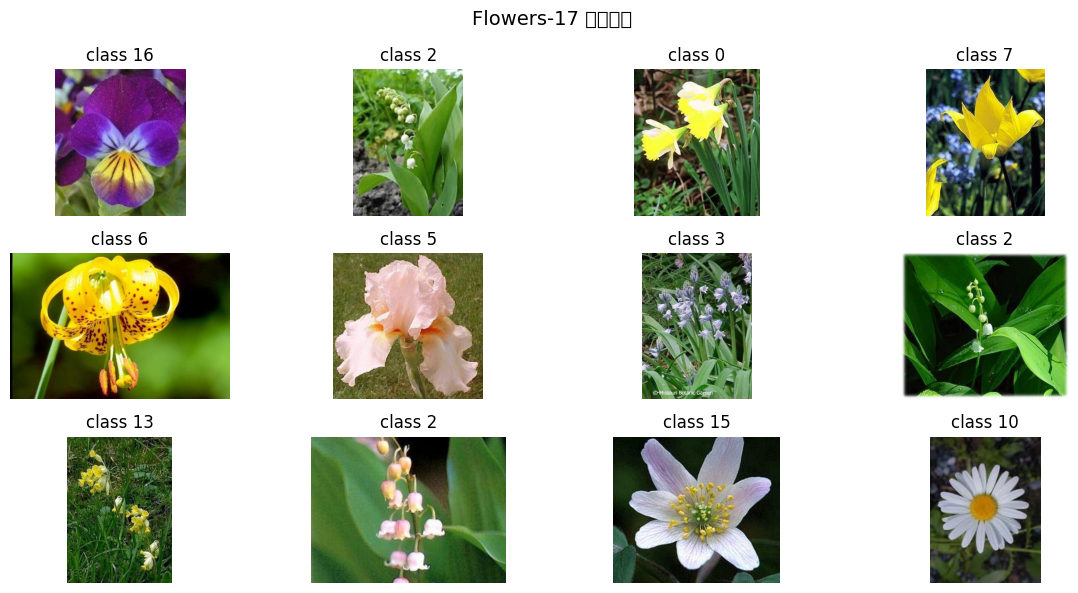

In [14]:
plt.figure(figsize=(12, 6))
for i in range(12):
    idx = random.choice(indices)
    img = Image.open(image_paths[idx]).convert("RGB")
    label = labels[idx]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"class {label}")
    plt.axis("off")

plt.suptitle("Flowers-17 随机样本", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
class Flowers17Dataset(Dataset):
    def __init__(self, image_paths, labels, indices, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img = Image.open(self.image_paths[real_idx]).convert("RGB")
        label = self.labels[real_idx]

        if self.transform:
            img = self.transform(img)

        return img, label

train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = Flowers17Dataset(image_paths, labels, train_idx, transform=train_tfms)
val_ds = Flowers17Dataset(image_paths, labels, val_idx, transform=val_test_tfms)
test_ds = Flowers17Dataset(image_paths, labels, test_idx, transform=val_test_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 31
Val batches  : 6
Test batches : 7


## DenseNet 特征融合模型

思路：
- 以 `DenseNet121` 为骨干网络（可使用 ImageNet 预训练权重）。
- 取出 `denseblock2 / denseblock3 / denseblock4` 的输出。
- 对每个 block 做全局平均池化，拼接后送入分类头。

这样可同时利用中层纹理信息和高层语义信息。

In [16]:
class DenseNetFusionClassifier(nn.Module):
    def __init__(self, num_classes=17, pretrained=True, dropout=0.3):
        super().__init__()

        if pretrained:
            weights = models.DenseNet121_Weights.IMAGENET1K_V1
        else:
            weights = None

        backbone = models.densenet121(weights=weights)
        self.features = backbone.features

        self._feat2 = None
        self._feat3 = None
        self._feat4 = None

        self.features.denseblock2.register_forward_hook(self._save_block2)
        self.features.denseblock3.register_forward_hook(self._save_block3)
        self.features.denseblock4.register_forward_hook(self._save_block4)

        # densenet121 各 block 输出通道：block2=512, block3=1024, block4=1024
        fusion_dim = 512 + 1024 + 1024
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _save_block2(self, module, input, output):
        self._feat2 = output

    def _save_block3(self, module, input, output):
        self._feat3 = output

    def _save_block4(self, module, input, output):
        self._feat4 = output

    @staticmethod
    def gap(x):
        return torch.flatten(torch.mean(x, dim=(2, 3), keepdim=False), 1)

    def forward(self, x):
        _ = self.features(x)
        f2 = self.gap(self._feat2)
        f3 = self.gap(self._feat3)
        f4 = self.gap(self._feat4)

        fused = torch.cat([f2, f3, f4], dim=1)
        logits = self.classifier(fused)
        return logits


model = DenseNetFusionClassifier(num_classes=num_classes, pretrained=True).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model.__class__.__name__)
print(f"可训练参数量: {num_params / 1e6:.2f} M")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\86133/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:53<00:00, 606kB/s] 


DenseNetFusionClassifier
可训练参数量: 8.27 M


## 训练与验证

这里使用较小 epoch（默认 8）以保证教学场景可较快完成。你可以在课后提高 epoch 观察模型变化。

In [17]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_targets = [], []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, targets)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc


EPOCHS = 8
best_val_acc = 0.0
best_state = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

print(f"\nBest Val Acc: {best_val_acc:.4f}")

Epoch 01/8 | Train Loss: 2.7876, Train Acc: 0.2006 | Val Loss: 2.6737, Val Acc: 0.5747


Epoch 02/8 | Train Loss: 2.4125, Train Acc: 0.6090 | Val Loss: 1.6884, Val Acc: 0.6724


Epoch 03/8 | Train Loss: 1.5333, Train Acc: 0.7240 | Val Loss: 0.9451, Val Acc: 0.8046


Epoch 04/8 | Train Loss: 0.8754, Train Acc: 0.8106 | Val Loss: 0.5878, Val Acc: 0.8908


Epoch 05/8 | Train Loss: 0.5561, Train Acc: 0.8910 | Val Loss: 0.4249, Val Acc: 0.9080


Epoch 06/8 | Train Loss: 0.4153, Train Acc: 0.9175 | Val Loss: 0.3781, Val Acc: 0.9253


Epoch 07/8 | Train Loss: 0.3804, Train Acc: 0.9277 | Val Loss: 0.3471, Val Acc: 0.9195


Epoch 08/8 | Train Loss: 0.3545, Train Acc: 0.9379 | Val Loss: 0.3464, Val Acc: 0.9023

Best Val Acc: 0.9253


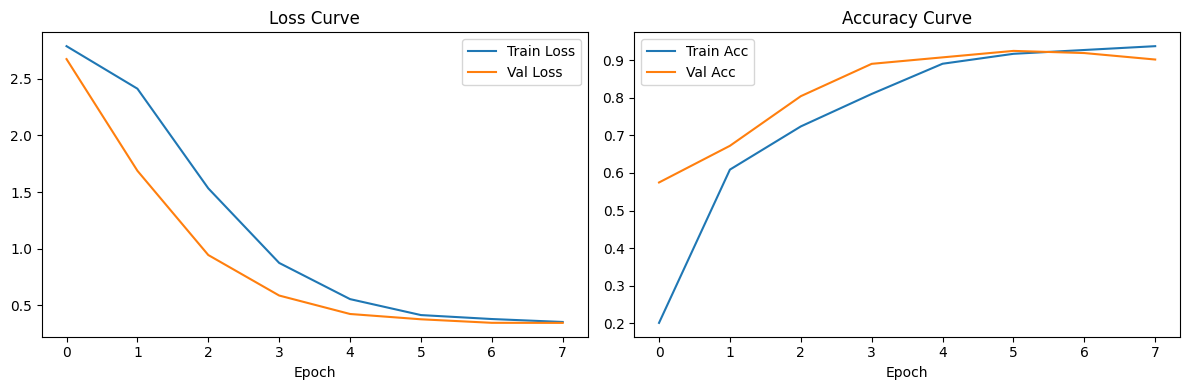

In [18]:
# 恢复最佳模型
if best_state is not None:
    model.load_state_dict(best_state)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

## 测试集评估与中间结果展示

这里输出：
- 测试集准确率
- 分类报告（precision / recall / F1）
- 混淆矩阵热力图
- 若干预测样例

In [19]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for images, targets in tqdm(test_loader):
        images = images.to(DEVICE)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()

        all_preds.extend(preds)
        all_targets.extend(targets.numpy().tolist())

test_acc = accuracy_score(all_targets, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, digits=4))

100%|██████████| 7/7 [00:01<00:00,  4.81it/s]

Test Accuracy: 0.9265

Classification Report:
              precision    recall  f1-score   support

           0     0.6471    0.9167    0.7586        12
           1     0.9231    1.0000    0.9600        12
           2     1.0000    1.0000    1.0000        12
           3     1.0000    1.0000    1.0000        12
           4     0.9167    0.9167    0.9167        12
           5     1.0000    0.9167    0.9565        12
           6     1.0000    1.0000    1.0000        12
           7     0.6250    0.4167    0.5000        12
           8     1.0000    0.9167    0.9565        12
           9     1.0000    1.0000    1.0000        12
          10     1.0000    1.0000    1.0000        12
          11     1.0000    0.9167    0.9565        12
          12     0.9231    1.0000    0.9600        12
          13     0.8333    0.8333    0.8333        12
          14     1.0000    1.0000    1.0000        12
          15     1.0000    0.9167    0.9565        12
          16     0.9231    1.0000  

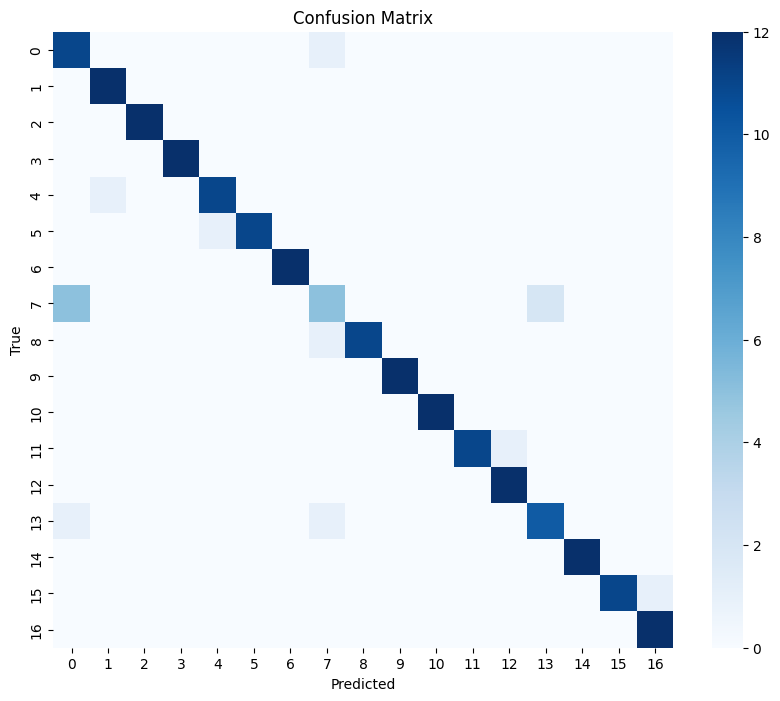

In [20]:
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

D:\Temp\ipykernel_19984\290892215.py:24: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_19984\290892215.py:24: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_19984\290892215.py:24: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_19984\290892215.py:24: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_19984\290892215.py:24: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_19984\290892215.py:24: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_19984\290892215.py:24: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from curren

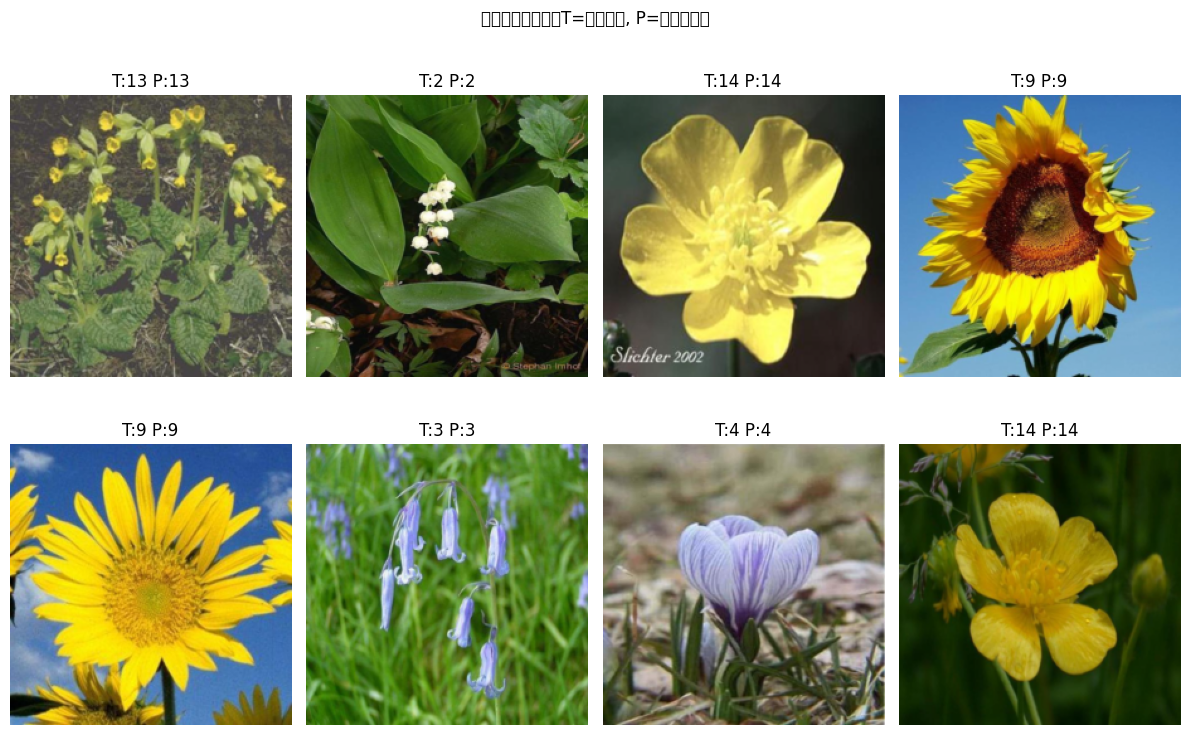

In [21]:
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225],
)

images_batch, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(DEVICE)

with torch.no_grad():
    logits = model(images_batch)
    pred_batch = logits.argmax(dim=1).cpu()

plt.figure(figsize=(12, 8))
for i in range(min(8, images_batch.size(0))):
    img = inv_normalize(images_batch[i].cpu()).clamp(0, 1)
    img_np = np.transpose(img.numpy(), (1, 2, 0))

    plt.subplot(2, 4, i + 1)
    plt.imshow(img_np)
    plt.title(f"T:{labels_batch[i].item()} P:{pred_batch[i].item()}")
    plt.axis("off")

plt.suptitle("测试集预测样例（T=真实标签, P=预测标签）")
plt.tight_layout()
plt.show()

## 教学拓展与思考（附参考解题思路）

### 思考 1：如果不用特征融合，只用 DenseNet 最后一层，会怎样？

**提示思路：**
- 将当前模型改为标准 `densenet121` 的最后分类头（`backbone.classifier = nn.Linear(...)`）。
- 保持同样训练轮次和增强策略，比较 `Val Acc / Test Acc`。
- 观察哪些类别在混淆矩阵中更易混淆，分析中层纹理信息是否有帮助。

---

### 思考 2：融合 block2/3/4 和只融合 block3/4 的差异？

**提示思路：**
- 在 `DenseNetFusionClassifier` 中做消融：
  - 方案 A：`[f2, f3, f4]`
  - 方案 B：`[f3, f4]`
  - 方案 C：`[f4]`
- 比较准确率与训练时间，讨论“更多特征”与“更高计算量”之间的权衡。

---

### 思考 3：如何进一步提升性能？

**提示思路：**
1. **训练策略**：增大 epoch、引入 warmup、尝试 `label smoothing`。
2. **数据增强**：加入 `RandAugment` 或 `MixUp/CutMix`。
3. **模型改进**：在融合后加入 SE/注意力模块。
4. **评估方法**：使用 K 折交叉验证，减少一次划分带来的随机性。

---

### 思考 4（进阶）：类别名称可解释化

当前标签是 `0~16` 的数字。请同学查阅 Flowers-17 官方类别名并建立映射，然后：
- 在可视化标题中显示真实类别名；
- 在分类报告中输出类别名；
- 分析最难类别是否与视觉相似性一致。

**解题方向：**
- 构建 `id_to_name` 字典；
- 在 `classification_report(..., target_names=...)` 传入名称列表；
- 混淆矩阵重点看互相误判最严重的类别对。